# import and ennvironment

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from visualizations import lineplots_4x4
from processing import filter_region
from scipy.optimize import curve_fit
from scipy.stats import gaussian_kde
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
import numpy as np
import seaborn as sns
from noise_seeds import noise_iterations

# load prediction arrays, create array objects

In [2]:
def load_arrs(arr_type: str, folder_path):
    if arr_type not in ['sum', 'mean', 'var', 'label']: raise ValueError ('---Insert "sum" or "mean" "var" or "label" as input---')
    return_arr = np.empty((110, 100, 7493)) if arr_type == 'sum' else np.empty((110, 7493))
    for arr_index in range(110):
        arr_temp = np.load(f'{folder_path}image{arr_index}/{arr_type}_arr_image{arr_index}.npy')
        return_arr[arr_index] = arr_temp
    return return_arr

In [3]:
folder_path_stochbin = 'predictions/8-27-2025/'
folder_path_sigma10 = 'predictions/sigma10'

In [4]:
stochbin_sum = load_arrs('sum', folder_path_stochbin)
stochbin_mean = load_arrs('mean', folder_path_stochbin)
stochbin_var = load_arrs('var', folder_path_stochbin)
stochbin_label = load_arrs('label', folder_path_stochbin)

In [5]:
# load for those in sigma10
"""
later need to make this generalize to different systems
"""
sigma10_sum = np.load(folder_path_sigma10 + "/sum_sigma10.npy")
sigma10_mean = np.load(folder_path_sigma10 + "/mean_sigma10.npy")
sigma10_var = np.load(folder_path_sigma10 + "/var_sigma10.npy")
sigma10_label = np.load(folder_path_sigma10 + "/labels_sigma10.npy")

# get mean and var arrays from V1
filtering done as well

get region 1 here

In [6]:
v1mean_stochbin = filter_region(1, stochbin_label, stochbin_mean)
v1var_stochbin = filter_region(1, stochbin_label, stochbin_var)

"""
NOTE USING LABELS FROM V1MEAN TO FILTER HERE, ASSUMING THIS IS FINE SINCE IT IS THE SAME NEURONS 
"""

v1mean_sigma10 = filter_region(1, stochbin_label, sigma10_mean)
v1var_sigma10 = filter_region(1, stochbin_label, sigma10_var)

In [7]:
# delete 9 grey images

v1mean_sigma10 = v1mean_sigma10[9:, ...]
v1var_sigma10 = v1var_sigma10[9:,...]
v1mean_stochbin = v1mean_stochbin[9:,...]
v1var_stochbin = v1var_stochbin[9:,...]

# remove values

after 11/20 meeting removing anything >100

In [8]:
mask_gaus = v1mean_sigma10 <= 100
mask_bernoulli = v1mean_stochbin <= 100

In [9]:
v1mean_sigma10[~mask_gaus] = np.nan
v1var_sigma10[~mask_gaus] = np.nan
v1mean_stochbin[~mask_bernoulli] = np.nan
v1var_stochbin[~mask_bernoulli] = np.nan

# get indices to sort

In [10]:
stochbin_med = np.nanmedian(v1mean_stochbin, axis = 0)
sigma10_med = np.nanmedian(v1mean_sigma10, axis = 0)

In [11]:
stochbin_sort_indices = np.argsort(stochbin_med)[::-1]
sigma10_sort_indices = np.argsort(sigma10_med)[::-1]

In [12]:
stochbin_meanv1 = v1mean_stochbin[..., stochbin_sort_indices]
stochbin_varv1 = v1var_stochbin[..., stochbin_sort_indices]

sigma10_meanv1 = v1mean_sigma10[..., sigma10_sort_indices]
sigma10_varv1 = v1var_sigma10[..., sigma10_sort_indices]

# Figure 1

In [13]:
def figure1_collection(stochbin_sum, sigma10_sum, 
                       num_imgs=100, num_noise_seeds=10, num_frames=15,
                       img_height=144, img_width=256, relu_threshold=128):
    """
    Collect and compute pixel-space statistics for Figure 1.
    
    Parameters:
    -----------
    stochbin_sum : ndarray
        Sum array for stochastic binary (Bernoulli) noise, shape (num_imgs, num_neurons)
    sigma10_sum : ndarray
        Sum array for Gaussian noise (sigma=10), shape (num_imgs, num_neurons)
    num_imgs : int, default=100
        Number of images
    num_noise_seeds : int, default=10
        Number of noise seeds
    num_frames : int, default=15
        Number of frames to sum over
    img_height : int, default=144
        Height of images in pixels
    img_width : int, default=256
        Width of images in pixels
    relu_threshold : int, default=128
        Threshold for ReLU operation
        
    Returns:
    --------
    dict : Dictionary containing:
        - 'gnoise_mean': Gaussian noise mean (flattened)
        - 'gnoise_var': Gaussian noise variance (flattened)
        - 'bnoise_mean': Bernoulli noise mean (flattened)
        - 'bnoise_var': Bernoulli noise variance (flattened)
        - 'fg_mean_relu': Gaussian ReLU mean (flattened)
        - 'fg_var_relu': Gaussian ReLU variance (flattened)
        - 'fb_mean_relu': Bernoulli ReLU mean (flattened)
        - 'fb_var_relu': Bernoulli ReLU variance (flattened)
    """
    from scipy.optimize import curve_fit
    
    total_pixels = img_height * img_width
    
    # Assuming stochbin_sum and sigma10_sum are already summed across frames
    # and have shape (num_imgs, num_noise_seeds, total_pixels)
    # If they're not, we need to compute them from the full noise arrays
    
    # For now, assuming they need to be generated from scratch
    # Load data
    image_df = np.load("image_stacks/imagestack_nov232025(first100).npy")
    
    def get_noise_per_image(img, num_frames, num_noise_seeds, noise_type: str, sigma: int, stoch_bin_param):
        """Generate noise for a single image across multiple frames and noise seeds."""
        if img.ndim != 3:
            img = np.array(img).reshape((1, img.shape[0], img.shape[1]))
        tiled_img = np.tile(img, (num_frames, 1, 1))
        return np.array(noise_iterations(
            "_", "_", noise_type, num_noise_seeds, tiled_img, sigma,
            stochastic_bin_param=stoch_bin_param,
            scans=[[4, 7]], 
            num_frames=num_frames, 
            return_noise=True
        ))
    
    # Generate 15-frame noise arrays
    noise_arr_gaus = np.empty((num_imgs, num_noise_seeds, num_frames, img_height, img_width))
    noise_arr_bern = np.empty((num_imgs, num_noise_seeds, num_frames, img_height, img_width))
    
    for i in range(num_imgs):
        noise_arr_gaus[i] = get_noise_per_image(image_df[i], num_frames, num_noise_seeds, "dynamic", 10, False)
        noise_arr_bern[i] = get_noise_per_image(image_df[i], num_frames, num_noise_seeds, "dynamic", 10, True)
    
    # Reshape to flatten spatial dimensions
    noise_arr_fg = noise_arr_gaus.reshape(num_imgs, num_noise_seeds, num_frames, total_pixels).astype(np.float32)
    noise_arr_bern = noise_arr_bern.reshape(num_imgs, num_noise_seeds, num_frames, total_pixels).astype(np.float32)
    
    # Compute mean and variance - Regular data (15 frames summed)
    gaus_summed = np.sum(noise_arr_fg, axis=2)
    gnoise_mean = np.mean(gaus_summed, axis=1).flatten()
    gnoise_var = np.var(gaus_summed, axis=1).flatten()
    
    bern_summed = np.sum(noise_arr_bern, axis=2)
    bnoise_mean = np.mean(bern_summed, axis=1).flatten()
    bnoise_var = np.var(bern_summed, axis=1).flatten()
    
    # Compute mean and variance - ReLU data (15 frames summed)
    fg_relu = np.where(noise_arr_fg >= relu_threshold, noise_arr_fg, 0)
    grelu_sum = np.sum(fg_relu, axis=2)
    fg_mean_relu = np.mean(grelu_sum, axis=1).flatten()
    fg_var_relu = np.var(grelu_sum, axis=1).flatten()
    
    fb_relu = np.where(noise_arr_bern >= relu_threshold, noise_arr_bern, 0)
    fb_relu_sum = np.sum(fb_relu, axis=2)
    fb_mean_relu = np.mean(fb_relu_sum, axis=1).flatten()
    fb_var_relu = np.var(fb_relu_sum, axis=1).flatten()
    
    print(f"Pixel-space data collection complete:")
    print(f"  Gaussian noise: {gnoise_mean.shape}")
    print(f"  Bernoulli noise: {bnoise_mean.shape}")
    print(f"  Gaussian ReLU: {fg_mean_relu.shape}")
    print(f"  Bernoulli ReLU: {fb_mean_relu.shape}")
    
    return {
        'gnoise_mean': gnoise_mean,
        'gnoise_var': gnoise_var,
        'bnoise_mean': bnoise_mean,
        'bnoise_var': bnoise_var,
        'fg_mean_relu': fg_mean_relu,
        'fg_var_relu': fg_var_relu,
        'fb_mean_relu': fb_mean_relu,
        'fb_var_relu': fb_var_relu
    }

In [14]:
# First, run the data collection
pixel_data = figure1_collection(
     stochbin_sum=stochbin_sum,
    sigma10_sum=sigma10_sum,
     num_imgs=100,
     num_noise_seeds=10,
    num_frames=15,
     img_height=144,
     img_width=256,
     relu_threshold=128
 )

Pixel-space data collection complete:
  Gaussian noise: (3686400,)
  Bernoulli noise: (3686400,)
  Gaussian ReLU: (3686400,)
  Bernoulli ReLU: (3686400,)


In [15]:
# ==============================================================================
# NEURON-LEVEL AND PIXEL-LEVEL FITTING FOR FIGURE 1
# ==============================================================================
from scipy.stats import linregress
from scipy.optimize import curve_fit

# Unpack pixel-level data from figure1_collection()
gnoise_mean = pixel_data['gnoise_mean']
gnoise_var = pixel_data['gnoise_var']
bnoise_mean = pixel_data['bnoise_mean']
bnoise_var = pixel_data['bnoise_var']
fg_mean_relu = pixel_data['fg_mean_relu']
fg_var_relu = pixel_data['fg_var_relu']
fb_mean_relu = pixel_data['fb_mean_relu']
fb_var_relu = pixel_data['fb_var_relu']

# ==============================================================================
# HELPER FUNCTIONS
# ==============================================================================
def power_law(x, a, b):
    """Power law function: y = a * x^b"""
    return a * (x ** b)

def axb_noslope(x, a, b):
    """Power law function without slope: y = a * x^b"""
    return a * (x ** b)

def smooth_from_logfit(x, log_intercept, b):
    """Convert log-space fit to linear space"""
    a = np.exp(log_intercept)
    return a * (x ** b)

def fit_log_power(x, y):
    """Fit power law in log-log space with zero intercept"""
    mask = (x > 0) & (y > 0) & np.isfinite(x) & np.isfinite(y)
    if mask.sum() < 2:
        return 1.0, np.nan, np.nan
    lx = np.log(x[mask])
    ly = np.log(y[mask])
    model = LinearRegression(fit_intercept=False)
    model.fit(lx.reshape(-1, 1), ly)
    b = model.coef_[0]
    y_pred = model.predict(lx.reshape(-1, 1))
    ss_res = np.sum((ly - y_pred)**2)
    ss_tot = np.sum((ly - np.mean(ly))**2)
    r2 = 1 - ss_res/ss_tot if ss_tot > 0 else np.nan
    return 1.0, b, r2

def fit_lin_power(x, y, a_initial=1.0, b_initial=1e-3):
    """Fit power law in linear space"""
    mask = (x > 0) & (y > 0) & np.isfinite(x) & np.isfinite(y)
    if mask.sum() < 2:
        return np.nan, np.nan, np.nan
    xm = x[mask]
    ym = y[mask]
    try:
        params, _ = curve_fit(axb_noslope, xm, ym, maxfev=1_000_000, p0=[a_initial, b_initial])
        a_lin, b_lin = params
        y_hat = axb_noslope(xm, a_lin, b_lin)
        ss_res = np.sum((ym - y_hat)**2)
        ss_tot = np.sum((ym - np.mean(ym))**2)
        r2_lin = 1 - ss_res/ss_tot if ss_tot > 0 else np.nan
        return a_lin, b_lin, r2_lin
    except Exception:
        return np.nan, np.nan, np.nan

# ==============================================================================
# PER-NEURON FITTING (stochbin and sigma10)
# ==============================================================================
n_neurons = stochbin_meanv1.shape[-1]
mean_st, var_st = stochbin_meanv1, stochbin_varv1
mean_sg, var_sg = sigma10_meanv1, sigma10_varv1

# Initialize containers
stochbin_alist_lin, stochbin_blist_lin, stochbin_rsqlist_lin = [], [], []
sigma10_alist_lin, sigma10_blist_lin, sigma10_rsqlist_lin = [], [], []
stochbin_rsqlist_lin_model, sigma10_rsqlist_lin_model = [], []

# Fit per-neuron stochbin
for neuron in range(n_neurons):
    x = mean_st[..., neuron].astype(float)
    y = var_st[..., neuron].astype(float)
    
    # Linear-space power law fit
    a_lin, b_lin, r2_lin = fit_lin_power(x, y, a_initial=2.5e-3, b_initial=2.23)
    stochbin_alist_lin.append(a_lin)
    stochbin_blist_lin.append(b_lin)
    stochbin_rsqlist_lin.append(r2_lin)
    
    # Simple linear model fit (y = mx + b)
    mask = (x > 0) & (y > 0) & np.isfinite(x) & np.isfinite(y)
    if mask.sum() < 2:
        stochbin_rsqlist_lin_model.append(np.nan)
    else:
        slope, intercept, r_val, p_val, std_err = linregress(x[mask], y[mask])
        stochbin_rsqlist_lin_model.append(r_val**2)

# Fit per-neuron sigma10
for neuron in range(n_neurons):
    x = mean_sg[..., neuron].astype(float)
    y = var_sg[..., neuron].astype(float)
    
    # Linear-space power law fit
    a_lin, b_lin, r2_lin = fit_lin_power(x, y, a_initial=2.2e-4, b_initial=2.24)
    sigma10_alist_lin.append(a_lin)
    sigma10_blist_lin.append(b_lin)
    sigma10_rsqlist_lin.append(r2_lin)
    
    # Simple linear model fit (y = mx + b)
    mask = (x > 0) & (y > 0) & np.isfinite(x) & np.isfinite(y)
    if mask.sum() < 2:
        sigma10_rsqlist_lin_model.append(np.nan)
    else:
        slope, intercept, r_val, p_val, std_err = linregress(x[mask], y[mask])
        sigma10_rsqlist_lin_model.append(r_val**2)

# Convert to arrays
stochbin_alist_lin = np.array(stochbin_alist_lin)
stochbin_blist_lin = np.array(stochbin_blist_lin)
stochbin_rsqlist_lin = np.array(stochbin_rsqlist_lin)
stochbin_rsqlist_lin_model = np.array(stochbin_rsqlist_lin_model)

sigma10_alist_lin = np.array(sigma10_alist_lin)
sigma10_blist_lin = np.array(sigma10_blist_lin)
sigma10_rsqlist_lin = np.array(sigma10_rsqlist_lin)
sigma10_rsqlist_lin_model = np.array(sigma10_rsqlist_lin_model)

# ==============================================================================
# GLOBAL POOLED FITS (linear space)
# ==============================================================================
# Fit global linear-space model on all stochbin data
x_all_st_lin = mean_st.flatten()
y_all_st_lin = var_st.flatten()
mask_st_lin = (x_all_st_lin > 0) & (y_all_st_lin > 0) & np.isfinite(x_all_st_lin) & np.isfinite(y_all_st_lin)
try:
    params_glob_st_lin, _ = curve_fit(axb_noslope, x_all_st_lin[mask_st_lin], y_all_st_lin[mask_st_lin], 
                                      maxfev=1_000_000, p0=[1, 0.001])
    a_glob_st_lin, b_glob_st_lin = params_glob_st_lin
except:
    a_glob_st_lin, b_glob_st_lin = np.nan, np.nan

# Fit global linear-space model on all sigma10 data
x_all_sg_lin = mean_sg.flatten()
y_all_sg_lin = var_sg.flatten()
mask_sg_lin = (x_all_sg_lin > 0) & (y_all_sg_lin > 0) & np.isfinite(x_all_sg_lin) & np.isfinite(y_all_sg_lin)
try:
    params_glob_sg_lin, _ = curve_fit(axb_noslope, x_all_sg_lin[mask_sg_lin], y_all_sg_lin[mask_sg_lin],
                                      maxfev=1_000_000, p0=[1, 0.001])
    a_glob_sg_lin, b_glob_sg_lin = params_glob_sg_lin
except:
    a_glob_sg_lin, b_glob_sg_lin = np.nan, np.nan

# Global linear fit (y = mx + b) for stochbin
if mask_st_lin.sum() >= 2:
    slope_glob_st, intercept_glob_st, _, _, _ = linregress(x_all_st_lin[mask_st_lin], y_all_st_lin[mask_st_lin])
else:
    slope_glob_st, intercept_glob_st = np.nan, np.nan

# Global linear fit (y = mx + b) for sigma10
if mask_sg_lin.sum() >= 2:
    slope_glob_sg, intercept_glob_sg, _, _, _ = linregress(x_all_sg_lin[mask_sg_lin], y_all_sg_lin[mask_sg_lin])
else:
    slope_glob_sg, intercept_glob_sg = np.nan, np.nan

# ==============================================================================
# PER-NEURON R² USING GLOBAL PARAMETERS
# ==============================================================================
# Pooled power law R²
pooled_stochbin_lin, pooled_sigma10_lin = [], []
pooled_stochbin_lin_model, pooled_sigma10_lin_model = [], []

for neuron in range(n_neurons):
    # Stochbin power law
    x = mean_st[:, neuron].astype(float)
    y = var_st[:, neuron].astype(float)
    mask = (x > 0) & (y > 0) & np.isfinite(x) & np.isfinite(y)
    if mask.sum() < 2:
        pooled_stochbin_lin.append(np.nan)
        pooled_stochbin_lin_model.append(np.nan)
    else:
        x_m, y_m = x[mask], y[mask]
        # Power law
        y_hat = axb_noslope(x_m, a_glob_st_lin, b_glob_st_lin)
        ss_res = np.sum((y_m - y_hat)**2)
        ss_tot = np.sum((y_m - np.mean(y_m))**2)
        pooled_stochbin_lin.append(1 - ss_res/ss_tot if ss_tot > 0 else np.nan)
        # Linear model
        y_hat_lin = slope_glob_st * x_m + intercept_glob_st
        ss_res_lin = np.sum((y_m - y_hat_lin)**2)
        pooled_stochbin_lin_model.append(1 - ss_res_lin/ss_tot if ss_tot > 0 else np.nan)
    
    # Sigma10 power law
    x = mean_sg[:, neuron].astype(float)
    y = var_sg[:, neuron].astype(float)
    mask = (x > 0) & (y > 0) & np.isfinite(x) & np.isfinite(y)
    if mask.sum() < 2:
        pooled_sigma10_lin.append(np.nan)
        pooled_sigma10_lin_model.append(np.nan)
    else:
        x_m, y_m = x[mask], y[mask]
        # Power law
        y_hat = axb_noslope(x_m, a_glob_sg_lin, b_glob_sg_lin)
        ss_res = np.sum((y_m - y_hat)**2)
        ss_tot = np.sum((y_m - np.mean(y_m))**2)
        pooled_sigma10_lin.append(1 - ss_res/ss_tot if ss_tot > 0 else np.nan)
        # Linear model
        y_hat_lin = slope_glob_sg * x_m + intercept_glob_sg
        ss_res_lin = np.sum((y_m - y_hat_lin)**2)
        pooled_sigma10_lin_model.append(1 - ss_res_lin/ss_tot if ss_tot > 0 else np.nan)

pooled_stochbin_lin = np.array(pooled_stochbin_lin)
pooled_sigma10_lin = np.array(pooled_sigma10_lin)
pooled_stochbin_lin_model = np.array(pooled_stochbin_lin_model)
pooled_sigma10_lin_model = np.array(pooled_sigma10_lin_model)

# ==============================================================================
# PIXEL-LEVEL POWER LAW FITS
# ==============================================================================
# Fit Bernoulli data
mask_b = (bnoise_mean > 0) & (bnoise_var > 0) & np.isfinite(bnoise_mean) & np.isfinite(bnoise_var)
if mask_b.sum() > 2:
    params_b_pixel, _ = curve_fit(power_law, bnoise_mean[mask_b], bnoise_var[mask_b], 
                                    maxfev=1_000_000, p0=[1, 2])
    x_fit_b = np.linspace(bnoise_mean[mask_b].min(), bnoise_mean[mask_b].max(), 100)
    y_fit_b = power_law(x_fit_b, *params_b_pixel)
else:
    params_b_pixel, x_fit_b, y_fit_b = None, None, None

# Bernoulli pooled regression
if a_glob_st_lin is not None and b_glob_st_lin is not None and np.isfinite(a_glob_st_lin) and np.isfinite(b_glob_st_lin):
    x_pooled_b = np.linspace(bnoise_mean[mask_b].min(), bnoise_mean[mask_b].max(), 100)
    y_pooled_b = power_law(x_pooled_b, a_glob_st_lin, b_glob_st_lin)
else:
    x_pooled_b, y_pooled_b = None, None

# Fit Bernoulli ReLU data
mask_br = (fb_mean_relu > 0) & (fb_var_relu > 0) & np.isfinite(fb_mean_relu) & np.isfinite(fb_var_relu)
if mask_br.sum() > 2:
    params_br_pixel, _ = curve_fit(power_law, fb_mean_relu[mask_br], fb_var_relu[mask_br], 
                                     maxfev=1_000_000, p0=[1, 2])
    x_fit_br = np.linspace(fb_mean_relu[mask_br].min(), fb_mean_relu[mask_br].max(), 100)
    y_fit_br = power_law(x_fit_br, *params_br_pixel)
else:
    params_br_pixel, x_fit_br, y_fit_br = None, None, None

# Bernoulli ReLU pooled regression
if a_glob_st_lin is not None and b_glob_st_lin is not None and np.isfinite(a_glob_st_lin) and np.isfinite(b_glob_st_lin):
    x_pooled_br = np.linspace(fb_mean_relu[mask_br].min(), fb_mean_relu[mask_br].max(), 100)
    y_pooled_br = power_law(x_pooled_br, a_glob_st_lin, b_glob_st_lin)
else:
    x_pooled_br, y_pooled_br = None, None

# Fit Gaussian data
mask_g = (gnoise_mean > 0) & (gnoise_var > 0) & np.isfinite(gnoise_mean) & np.isfinite(gnoise_var)
if mask_g.sum() > 2:
    params_g_pixel, _ = curve_fit(power_law, gnoise_mean[mask_g], gnoise_var[mask_g], 
                                    maxfev=1_000_000, p0=[1, 2])
    x_fit_g = np.linspace(gnoise_mean[mask_g].min(), gnoise_mean[mask_g].max(), 100)
    y_fit_g = power_law(x_fit_g, *params_g_pixel)
else:
    params_g_pixel, x_fit_g, y_fit_g = None, None, None

# Gaussian pooled regression
if a_glob_sg_lin is not None and b_glob_sg_lin is not None and np.isfinite(a_glob_sg_lin) and np.isfinite(b_glob_sg_lin):
    x_pooled_g = np.linspace(gnoise_mean[mask_g].min(), gnoise_mean[mask_g].max(), 100)
    y_pooled_g = power_law(x_pooled_g, a_glob_sg_lin, b_glob_sg_lin)
else:
    x_pooled_g, y_pooled_g = None, None

# Fit Gaussian ReLU data
mask_gr = (fg_mean_relu > 0) & (fg_var_relu > 0) & np.isfinite(fg_mean_relu) & np.isfinite(fg_var_relu)
if mask_gr.sum() > 2:
    params_gr_pixel, _ = curve_fit(power_law, fg_mean_relu[mask_gr], fg_var_relu[mask_gr], 
                                     maxfev=1_000_000, p0=[1, 2])
    x_fit_gr = np.linspace(fg_mean_relu[mask_gr].min(), fg_mean_relu[mask_gr].max(), 100)
    y_fit_gr = power_law(x_fit_gr, *params_gr_pixel)
else:
    params_gr_pixel, x_fit_gr, y_fit_gr = None, None, None

# Gaussian ReLU pooled regression
if a_glob_sg_lin is not None and b_glob_sg_lin is not None and np.isfinite(a_glob_sg_lin) and np.isfinite(b_glob_sg_lin):
    x_pooled_gr = np.linspace(fg_mean_relu[mask_gr].min(), fg_mean_relu[mask_gr].max(), 100)
    y_pooled_gr = power_law(x_pooled_gr, a_glob_sg_lin, b_glob_sg_lin)
else:
    x_pooled_gr, y_pooled_gr = None, None

print(f"Fitting complete:")
print(f"  Stochbin global params: a={a_glob_st_lin:.2e}, b={b_glob_st_lin:.2f}")
print(f"  Sigma10 global params: a={a_glob_sg_lin:.2e}, b={b_glob_sg_lin:.2f}")

Fitting complete:
  Stochbin global params: a=2.53e-03, b=2.23
  Sigma10 global params: a=2.24e-04, b=2.24


In [16]:
# ==============================================================================
# FIGURE 1: MAIN PLOTTING
# ==============================================================================

def plot_figure1(stochbin_meanv1, stochbin_varv1, sigma10_meanv1, sigma10_varv1,
                 gnoise_mean, gnoise_var, bnoise_mean, bnoise_var,
                 fg_mean_relu, fg_var_relu, fb_mean_relu, fb_var_relu,
                 stochbin_rsqlist_lin, sigma10_rsqlist_lin,
                 stochbin_rsqlist_lin_model, sigma10_rsqlist_lin_model,
                 pooled_stochbin_lin, pooled_sigma10_lin,
                 pooled_stochbin_lin_model, pooled_sigma10_lin_model,
                 stochbin_blist_lin, sigma10_blist_lin,
                 a_glob_st_lin, b_glob_st_lin, a_glob_sg_lin, b_glob_sg_lin,
                 params_b_pixel, params_br_pixel, params_g_pixel, params_gr_pixel,
                 x_fit_b, y_fit_b, x_fit_br, y_fit_br,
                 x_fit_g, y_fit_g, x_fit_gr, y_fit_gr,
                 x_pooled_b, y_pooled_b, x_pooled_br, y_pooled_br,
                 x_pooled_g, y_pooled_g, x_pooled_gr, y_pooled_gr,
                 ve_thresh=0.1, neuron_idx=2, savefig=False):
    """
    Create Figure 1 with all subpanels.
    
    Parameters:
    -----------
    All neuron-level and pixel-level statistics and fits
    ve_thresh : float, default=0.1
        Variance explained threshold
    neuron_idx : int, default=2
        Index of neuron to highlight (Neuron 3 = index 2)
    """
    import matplotlib.pyplot as plt
    import matplotlib.gridspec as gridspec
    from matplotlib.lines import Line2D
    from matplotlib.ticker import MaxNLocator
    import seaborn as sns
    from sklearn.linear_model import LinearRegression
    from scipy.optimize import curve_fit
    
    # Helper functions
    def safe_mask(x, y):
        """Return masked x and y arrays for valid (positive, finite) values"""
        xa = np.asarray(x).astype(float).flatten()
        ya = np.asarray(y).astype(float).flatten()
        mask = (xa > 0) & (ya > 0) & np.isfinite(xa) & np.isfinite(ya)
        return xa[mask], ya[mask]
    
    def axb_noslope(x, a, b):
        """Power law function: y = a * x^b"""
        return a * (x ** b)
    
    def smooth_from_logfit(x, log_intercept, b):
        """Convert log-space fit to linear space"""
        a = np.exp(log_intercept)
        return a * (x ** b)
    
    def fit_log_power(x, y):
        """Fit power law in log-log space with zero intercept"""
        mask = (x > 0) & (y > 0) & np.isfinite(x) & np.isfinite(y)
        if mask.sum() < 2:
            return 1.0, np.nan, np.nan
        lx = np.log(x[mask])
        ly = np.log(y[mask])
        model = LinearRegression(fit_intercept=True)
        model.fit(lx.reshape(-1, 1), ly)
        b = model.coef_[0]
        return 1.0, b, np.nan
    
    # Create figure
    fig = plt.figure(figsize=(15, 12))
    outer = gridspec.GridSpec(2, 2, figure=fig, wspace=0.3, hspace=0.3)
    
    # ==============================================================================
    # TOP LEFT: Selected Neuron (Neuron 3) - 2x2 nested grid
    # ==============================================================================
    inner_tl = gridspec.GridSpecFromSubplotSpec(2, 2, subplot_spec=outer[0, 0], wspace=0.3, hspace=0.3)
    
    # Data for Neuron 3
    xg, yg = safe_mask(sigma10_meanv1[neuron_idx], sigma10_varv1[neuron_idx])
    xb, yb = safe_mask(stochbin_meanv1[neuron_idx], stochbin_varv1[neuron_idx])
    
    # Fits for Gaussian
    if xg.size > 1:
        logxg = np.log(xg)
        logyg = np.log(yg)
        if np.isfinite(logxg).all() and np.isfinite(logyg).all():
            model_g = LinearRegression(fit_intercept=True)
            model_g.fit(logxg.reshape(-1, 1), logyg)
            class LogFitResult:
                def __init__(self, slope, intercept):
                    self.slope = slope
                    self.intercept = intercept
            res_g = LogFitResult(model_g.coef_[0], model_g.intercept_)
            xg_fit_log = np.exp(np.linspace(np.log(xg.min()), np.log(xg.max()), 100))
            yg_fit_log = smooth_from_logfit(xg_fit_log, res_g.intercept, res_g.slope)
        else:
            res_g = None
            xg_fit_log, yg_fit_log = [], []
        
        params_g, _ = curve_fit(axb_noslope, xg, yg, maxfev=1_000_000, p0=[1, 0.001])
        xg_fit_lin = np.linspace(xg.min(), xg.max(), 100)
        yg_fit_lin = smooth_from_logfit(xg_fit_lin, np.log(params_g[0]), params_g[1])
    else:
        res_g = None
        xg_fit_log, yg_fit_log = [], []
        xg_fit_lin, yg_fit_lin = [], []
        params_g = [np.nan, np.nan]
    
    # Fits for Bernoulli
    if xb.size > 1:
        logxb = np.log(xb)
        logyb = np.log(yb)
        if np.isfinite(logxb).all() and np.isfinite(logyb).all():
            model_b = LinearRegression(fit_intercept=True)
            model_b.fit(logxb.reshape(-1, 1), logyb)
            res_b = LogFitResult(model_b.coef_[0], model_b.intercept_)
            xb_fit_log = np.exp(np.linspace(np.log(xb.min()), np.log(xb.max()), 100))
            yb_fit_log = smooth_from_logfit(xb_fit_log, res_b.intercept, res_b.slope)
        else:
            res_b = None
            xb_fit_log, yb_fit_log = [], []
        
        params_b, _ = curve_fit(axb_noslope, xb, yb, maxfev=1_000_000, p0=[1, 0.001])
        xb_fit_lin = np.linspace(xb.min(), xb.max(), 100)
        yb_fit_lin = smooth_from_logfit(xb_fit_lin, np.log(params_b[0]), params_b[1])
    else:
        res_b = None
        xb_fit_log, yb_fit_log = [], []
        xb_fit_lin, yb_fit_lin = [], []
        params_b = [np.nan, np.nan]
    
    # TL Subplots
    # 1. Gaussian Linear
    ax = fig.add_subplot(inner_tl[0, 1])
    ax.scatter(xg, yg, s=10, label='Data', marker=".", alpha=0.5)
    if len(xg_fit_lin): ax.plot(xg_fit_lin, yg_fit_lin, "r-", label='Fit')
    ax.plot([0, xg.max()], [0, xg.max()], 'k--', alpha=0.5)
    ax.set_title("Gaussian Noise")
    if len(xg_fit_lin):
        ax.text(0.01, 0.99, f"a={params_g[0]:.1e}\nb={params_g[1]:.1f}", 
                transform=ax.transAxes, verticalalignment='top', horizontalalignment='left', fontsize=10)
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 5)
    
    bbox = ax.get_position()
    fig.text(bbox.x1 - .17, bbox.y1 + 0.02, f"Select V1 Neuron\na · mean^b",
             ha='center', va='bottom', fontsize=14, fontweight='bold', transform=fig.transFigure)
    
    # 2. Gaussian Log
    ax = fig.add_subplot(inner_tl[1, 1])
    ax.loglog(xg, yg, '.', label='Data', alpha=0.1)
    if len(xg_fit_log): ax.loglog(xg_fit_log, yg_fit_log, 'r-', label='Fit')
    ax.plot([xg.min(), xg.max()], [xg.min(), xg.max()], 'k--', alpha=0.5)
    ax.set_xlabel('Mean Spike Count')
    if res_g:
        ax.text(0.01, 0.99, f"a={np.exp(res_g.intercept):.1e}\nb={res_g.slope:.1f}", 
                transform=ax.transAxes, verticalalignment='top', horizontalalignment='left', fontsize=10)
    ax.set_xlim(0.1, 100)
    ax.set_ylim(10e-7, 10e2)
    
    # 3. Bernoulli Linear
    ax = fig.add_subplot(inner_tl[0, 0])
    ax.scatter(xb, yb, s=10, color='tab:orange', label='Data', marker=".", alpha=0.5)
    if len(xb_fit_lin): ax.plot(xb_fit_lin, yb_fit_lin, 'r-', label='Fit')
    ax.plot([0, xb.max()], [0, xb.max()], 'k--', alpha=0.5)
    ax.set_ylabel('Variance in Spike Counts')
    ax.set_title("Bernoulli Noise")
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 100)
    if len(xb_fit_lin):
        ax.text(0.01, 0.99, f"a={params_b[0]:.1e}\nb={params_b[1]:.1f}", 
                transform=ax.transAxes, verticalalignment='top', horizontalalignment='left', fontsize=10)
    
    # 4. Bernoulli Log
    ax = fig.add_subplot(inner_tl[1, 0])
    ax.loglog(xb, yb, '.', color='tab:orange', label='Data', alpha=0.1)
    if len(xb_fit_log): ax.loglog(xb_fit_log, yb_fit_log, 'r-', label='Fit')
    ax.plot([xb.min(), xb.max()], [xb.min(), xb.max()], 'k--', alpha=0.5)
    ax.set_xlabel('Mean Spike Count')
    ax.set_ylabel("Variance in Spike Counts")
    if res_b:
        ax.text(0.01, 0.99, f"a={np.exp(res_b.intercept):.1e}\nb={res_b.slope:.1f}", 
                transform=ax.transAxes, verticalalignment='top', horizontalalignment='left', fontsize=10)
    ax.set_xlim(0.1, 100)
    ax.set_ylim(10e-6, 10e2)
    
    # ==============================================================================
    # TOP RIGHT: All Neurons - 2x2 nested grid
    # ==============================================================================
    inner_tr = gridspec.GridSpecFromSubplotSpec(2, 2, subplot_spec=outer[0, 1], wspace=0.3, hspace=0.3)
    
    # Data for All Neurons
    xg_all, yg_all = safe_mask(sigma10_meanv1, sigma10_varv1)
    xb_all, yb_all = safe_mask(stochbin_meanv1, stochbin_varv1)
    
    # Fits for All Gaussian
    if xg_all.size > 1:
        logxg_all = np.log(xg_all)
        logyg_all = np.log(yg_all)
        model_ga = LinearRegression(fit_intercept=True)
        model_ga.fit(logxg_all.reshape(-1, 1), logyg_all)
        y_pred_ga = model_ga.predict(logxg_all.reshape(-1, 1))
        ss_res_ga = np.sum((logyg_all - y_pred_ga)**2)
        ss_tot_ga = np.sum((logyg_all - np.mean(logyg_all))**2)
        r2_ga = np.clip(1 - ss_res_ga/ss_tot_ga, 0, 1) if ss_tot_ga > 0 else 0
        r_value_ga = np.sqrt(r2_ga)
        class LogFitResult:
            def __init__(self, slope, intercept, rvalue):
                self.slope = slope
                self.intercept = intercept
                self.rvalue = rvalue
        res_ga = LogFitResult(model_ga.coef_[0], model_ga.intercept_, r_value_ga)
        xg_fit_a = np.exp(np.linspace(np.log(xg_all.min()), np.log(xg_all.max()), 100))
        yg_fit_a = smooth_from_logfit(xg_fit_a, res_ga.intercept, res_ga.slope)
        try:
            params_ga_lin, _ = curve_fit(axb_noslope, xg_all, yg_all, maxfev=1_000_000, p0=[1, 0.001])
        except Exception:
            params_ga_lin = [np.nan, np.nan]
    else:
        res_ga = None
        xg_fit_a, yg_fit_a = [], []
        params_ga_lin = [np.nan, np.nan]
    
    # Fits for All Bernoulli
    if xb_all.size > 1:
        logxb_all = np.log(xb_all)
        logyb_all = np.log(yb_all)
        model_ba = LinearRegression(fit_intercept=True)
        model_ba.fit(logxb_all.reshape(-1, 1), logyb_all)
        y_pred_ba = model_ba.predict(logxb_all.reshape(-1, 1))
        ss_res_ba = np.sum((logyb_all - y_pred_ba)**2)
        ss_tot_ba = np.sum((logyb_all - np.mean(logyb_all))**2)
        r2_ba = np.clip(1 - ss_res_ba/ss_tot_ba, 0, 1) if ss_tot_ba > 0 else 0
        r_value_ba = np.sqrt(r2_ba)
        res_ba = LogFitResult(model_ba.coef_[0], model_ba.intercept_, r_value_ba)
        xb_fit_a = np.exp(np.linspace(np.log(xb_all.min()), np.log(xb_all.max()), 100))
        yb_fit_a = smooth_from_logfit(xb_fit_a, res_ba.intercept, res_ba.slope)
        try:
            params_ba_lin, _ = curve_fit(axb_noslope, xb_all, yb_all, maxfev=1_000_000, p0=[1, 0.001])
        except Exception:
            params_ba_lin = [np.nan, np.nan]
    else:
        res_ba = None
        xb_fit_a, yb_fit_a = [], []
        params_ba_lin = [np.nan, np.nan]
    
    # TR Subplots
    # 1. Gaussian Linear
    ax = fig.add_subplot(inner_tr[0, 1])
    ax.scatter(xg_all, yg_all, s=1, alpha=0.1)
    if len(xg_fit_a): ax.plot(xg_fit_a, yg_fit_a, 'r-')
    ax.plot([0, xg_all.max()], [0, xg_all.max()], 'k--', alpha=0.5)
    ax.set_title('Gaussian Noise')
    a_lin_g = params_ga_lin[0]
    b_lin_g = params_ga_lin[1]
    ax.text(0.01, 0.99, f"a={a_lin_g:.1e}\nb={b_lin_g:.1f}",
            transform=ax.transAxes, va='top', ha='left', fontsize=10)
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 5)
    
    bbox = ax.get_position()
    fig.text(bbox.x1 - .17, bbox.y1 + 0.02, f"All Neurons\na · mean^b",
             ha='center', va='bottom', fontsize=14, fontweight='bold', transform=fig.transFigure)
    
    # 2. Gaussian Log
    ax = fig.add_subplot(inner_tr[1, 1])
    ax.loglog(xg_all, yg_all, '.', markersize=1, alpha=0.1)
    if len(xg_fit_a): ax.loglog(xg_fit_a, yg_fit_a, 'r-')
    ax.plot([0.1, 100], [0.1, 100], 'k--', alpha=0.5)
    ax.set_xlabel("Mean Spike Count")
    if res_ga:
        ax.text(0.01, 0.99, f"a={np.exp(res_ga.intercept):.1e}\nb={res_ga.slope:.1f}",
                transform=ax.transAxes, va='top', ha='left', fontsize=10)
    ax.set_xlim(0.1, 100)
    ax.set_ylim(10e-7, 10e2)
    
    # 3. Bernoulli Linear
    ax = fig.add_subplot(inner_tr[0, 0])
    ax.scatter(xb_all, yb_all, s=1, alpha=0.1, color='tab:orange')
    if len(xb_fit_a): ax.plot(xb_fit_a, yb_fit_a, 'r-')
    ax.plot([0, 100], [0, 100], 'k--', alpha=0.5)
    ax.set_title('Bernoulli Noise')
    ax.set_ylabel('Variance in Spike Counts')
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 100)
    a_lin_b = params_ba_lin[0]
    b_lin_b = params_ba_lin[1]
    ax.text(0.01, 0.99, f"a={a_lin_b:.1e}\nb={b_lin_b:.1f}",
            transform=ax.transAxes, va='top', ha='left', fontsize=10)
    
    # 4. Bernoulli Log
    ax = fig.add_subplot(inner_tr[1, 0])
    ax.loglog(xb_all, yb_all, '.', markersize=1, alpha=0.1, color='tab:orange')
    if len(xb_fit_a): ax.loglog(xb_fit_a, yb_fit_a, 'r-')
    ax.plot([0.1, 100], [0.1, 100], 'k--', alpha=0.5)
    ax.set_xlabel("Mean Spike Count")
    ax.set_ylabel("Variance in Spike Counts")
    if res_ba:
        ax.text(0.01, 0.99, f"a={np.exp(res_ba.intercept):.1e}\nb={res_ba.slope:.1f}",
                transform=ax.transAxes, va='top', ha='left', fontsize=10)
    ax.set_xlim(0.1, 100)
    ax.set_ylim(10e-6, 10e2)
    
    # ==============================================================================
    # BOTTOM LEFT: KDE and Statistics - 2x2 nested grid
    # ==============================================================================
    inner = gridspec.GridSpecFromSubplotSpec(2, 2, subplot_spec=outer[1, 0], wspace=0.3, hspace=0.5)
    
    # Extract pooled parameters from log-space fits
    pooled_a_gaussian = np.exp(res_ga.intercept) if res_ga else np.nan
    pooled_b_gaussian = res_ga.slope if res_ga else np.nan
    pooled_a_bernoulli = np.exp(res_ba.intercept) if res_ba else np.nan
    pooled_b_bernoulli = res_ba.slope if res_ba else np.nan
    
    # Get indices of neurons with variance explained > threshold
    def above_threshold(r2_array, thresh=0.1):
        r2 = np.asarray(r2_array, float)
        mask = np.isfinite(r2) & (r2 > thresh)
        return np.where(mask)[0]
    
    ve_idx_gaus = above_threshold(sigma10_rsqlist_lin, ve_thresh)
    ve_idx_bern = above_threshold(stochbin_rsqlist_lin, ve_thresh)
    
    # Compute log-space b values for the plot
    n_neurons = stochbin_meanv1.shape[-1]
    stochbin_blist = np.array([fit_log_power(stochbin_meanv1[..., i], stochbin_varv1[..., i])[1] for i in range(n_neurons)])
    sigma10_blist = np.array([fit_log_power(sigma10_meanv1[..., i], sigma10_varv1[..., i])[1] for i in range(n_neurons)])
    
    # [0,0] - B PLOT (slope distribution)
    ax = fig.add_subplot(inner[0, 0])
    sns.kdeplot(stochbin_blist[ve_idx_bern], label="Log Log Space", linestyle="--", color="tab:orange", ax=ax)
    sns.kdeplot(sigma10_blist[ve_idx_gaus], ax=ax, linestyle="--")
    """
    commenting out loglog plots
    """
    sns.kdeplot(stochbin_blist_lin[ve_idx_bern], label="Spike Count Space", color="tab:orange", ax=ax)
    sns.kdeplot(sigma10_blist_lin[ve_idx_gaus], color="tab:blue", ax=ax)
    ax.set_xlim(-1, 6)
    ax.set_title("power parameter (b)")
    
    ylim = ax.get_ylim()
    y_pos = ylim[0] + 0.99 * (ylim[1] - ylim[0])
    
    if np.isfinite(pooled_b_bernoulli):
        ax.scatter(pooled_b_bernoulli, y_pos, marker="v", s=70, edgecolor="k", color="tab:orange")
    if np.isfinite(pooled_b_gaussian):
        ax.scatter(pooled_b_gaussian, y_pos, marker="v", s=70, edgecolor="k", color="C0")
    if np.isfinite(b_glob_st_lin):
        ax.scatter(b_glob_st_lin, y_pos, marker="v", s=70, edgecolor="k", color="tab:orange")
    if np.isfinite(b_glob_sg_lin):
        ax.scatter(b_glob_sg_lin, y_pos, marker="v", s=70, edgecolor="k", color="C0")
    
    # [1,0] - R² PLOT (individual fits)
    ax = fig.add_subplot(inner[1, 0])
    
    def clean(arr, clip01=True):
        v = np.asarray(arr, float)
        v = v[np.isfinite(v)]
        if clip01:
            v = np.clip(v, 0, 1)
        return v
    
    def kde_r2(ax, arr, label, color, ls="-"):
        v = clean(arr, clip01=True)
        if v.size < 3:
            ax.text(0.05, 0.9, f"{label}: n={v.size}", transform=ax.transAxes)
            return
        sns.kdeplot(v, ax=ax, label=label, color=color, linestyle=ls,
                    bw_adjust=0.35, cut=0, clip=(0, 1), common_norm=False)
    
    kde_r2(ax, stochbin_rsqlist_lin, "Bernoulli: power law (linear space)", "tab:orange", "-")
    kde_r2(ax, stochbin_rsqlist_lin_model, "Bernoulli: linear model (y=mx+b)", "tab:orange", ":")
    kde_r2(ax, sigma10_rsqlist_lin, "Gaussian: power law (linear space)", "tab:blue", "-")
    kde_r2(ax, sigma10_rsqlist_lin_model, "Gaussian: linear model (y=mx+b)", "tab:blue", ":")
    
    ax.axvline(x=ve_thresh, color="0.5", linestyle="dashdot")
    ax.set_title("Variance Explained\nIndividual Neuron Model")
    
    # [1,1] - R² PLOT (pooled/all neurons)
    ax = fig.add_subplot(inner[1, 1])
    
    kde_r2(ax, pooled_stochbin_lin, "Bernoulli: power law pooled (linear space)", "tab:orange", "-")
    kde_r2(ax, pooled_stochbin_lin_model, "Bernoulli: linear model pooled (y=mx+b)", "tab:orange", ":")
    kde_r2(ax, pooled_sigma10_lin, "Gaussian: power law pooled (linear space)", "tab:blue", "-")
    kde_r2(ax, pooled_sigma10_lin_model, "Gaussian: linear model pooled (y=mx+b)", "tab:blue", ":")
    
    ax.axvline(x=ve_thresh, color="0.5", linestyle="dashdot")
    ax.set_title("Variance Explained\nAll Neuron Model")
    ax.set_xlim(0, 1.0)
    ax.set_ylim(0, 7)
    
    # [0,1] - Legend
    ax = fig.add_subplot(inner[0, 1])
    ax.axis('off')
    legend_elements = [
        Line2D([0], [0], marker='v', color='k', label='1 Model for All Neurons',
               markerfacecolor='k', markersize=8, linestyle='None', markeredgecolor='k'),
        Line2D([0], [0], color='k', label='Log-log Space', linestyle='--'),
        Line2D([0], [0], color='k', label='Spike Count Space', linestyle='-'),
        Line2D([0], [0], color='k', label='Linear Fit', linestyle=':')
    ]
    ax.legend(handles=legend_elements, loc='center', frameon=True, fontsize=10)
    
    # ==============================================================================
    # BOTTOM RIGHT: Pixel Space Analysis - 2x2 nested grid
    # ==============================================================================
    inner_br = gridspec.GridSpecFromSubplotSpec(2, 2, subplot_spec=outer[1, 1], wspace=0.3, hspace=0.4)
    
    # [0,0] - Bernoulli Noise (pixel level)
    ax = fig.add_subplot(inner_br[0, 0])
    ax.scatter(bnoise_mean, bnoise_var, marker=".", alpha=0.006, s=1.001, color='tab:orange')
    if x_fit_b is not None:
        ax.plot(x_fit_b, y_fit_b, 'r-', linewidth=2, label=f'Fit: a={params_b_pixel[0]:.2e}, b={params_b_pixel[1]:.2f}')
    if x_pooled_b is not None:
        ax.plot(x_pooled_b, y_pooled_b, 'k--', linewidth=2, label=f'Pooled: a={a_glob_st_lin:.2e}, b={b_glob_st_lin:.2f}')
    ax.set_ylabel("Variance in Pixel Value")
    ax.set_title("Bernoulli Noise")
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    ax.ticklabel_format(axis='y', style='scientific', scilimits=(0, 0))
    
    # [1,0] - Bernoulli Noise ReLU (pixel level)
    ax = fig.add_subplot(inner_br[1, 0])
    ax.scatter(fb_mean_relu, fb_var_relu, marker=".", alpha=0.006, s=1.001, color='tab:orange')
    if x_fit_br is not None:
        ax.plot(x_fit_br, y_fit_br, 'r-', linewidth=2, label=f'Fit: a={params_br_pixel[0]:.2e}, b={params_br_pixel[1]:.2f}')
    if x_pooled_br is not None:
        ax.plot(x_pooled_br, y_pooled_br, 'k--', linewidth=2, label=f'Pooled: a={a_glob_st_lin:.2e}, b={b_glob_st_lin:.2f}')
    ax.set_xlabel("Mean Pixel Value")
    ax.set_ylabel("Variance in Pixel Value")
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    ax.ticklabel_format(axis='y', style='scientific', scilimits=(0, 0))
    ax.set_title("Bernoulli RELU")
    
    # [0,1] - Gaussian Noise (pixel level)
    ax = fig.add_subplot(inner_br[0, 1])
    ax.scatter(gnoise_mean, gnoise_var, marker=".", alpha=0.006, s=1.001, color='tab:blue')
    if x_fit_g is not None:
        ax.plot(x_fit_g, y_fit_g, 'r-', linewidth=2, label=f'Fit: a={params_g_pixel[0]:.2e}, b={params_g_pixel[1]:.2f}')
    if x_pooled_g is not None:
        ax.plot(x_pooled_g, y_pooled_g, 'k--', linewidth=2, label=f'Pooled: a={a_glob_sg_lin:.2e}, b={b_glob_sg_lin:.2f}')
    ax.set_title("Gaussian Noise")
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    ax.set_ylim(0, 6000)
    ax.ticklabel_format(axis='y', style='scientific', scilimits=(0, 0))
    

    # [1,1] - Gaussian Noise ReLU (pixel level)
    ax = fig.add_subplot(inner_br[1, 1])
    ax.scatter(fg_mean_relu, fg_var_relu, marker=".", alpha=0.006, s=1.001, color='tab:blue')
    if x_fit_gr is not None:
        ax.plot(x_fit_gr, y_fit_gr, 'r-', linewidth=2, label=f'Fit: a={params_gr_pixel[0]:.2e}, b={params_gr_pixel[1]:.2f}')
    if x_pooled_gr is not None:
        ax.plot(x_pooled_gr, y_pooled_gr, 'k--', linewidth=2, label=f'Pooled: a={a_glob_sg_lin:.2e}, b={b_glob_sg_lin:.2f}')
    ax.set_xlabel("Mean Pixel Value")
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    ax.ticklabel_format(axis='y', style='scientific', scilimits=(0, 0))
    ax.set_title("Gaussian RELU")
    
    # Add title above bottom-right plot
    bbox = ax.get_position()
    fig.text(bbox.x1 - .17, bbox.y1+0.225, "Pixel Space Analysis",
             ha='center', va='bottom', fontsize=14, fontweight='bold', transform=fig.transFigure)
    
    if savefig: 
        plt.savefig("figure1.png")
        plt.close()
    else: plt.show()
    return fig

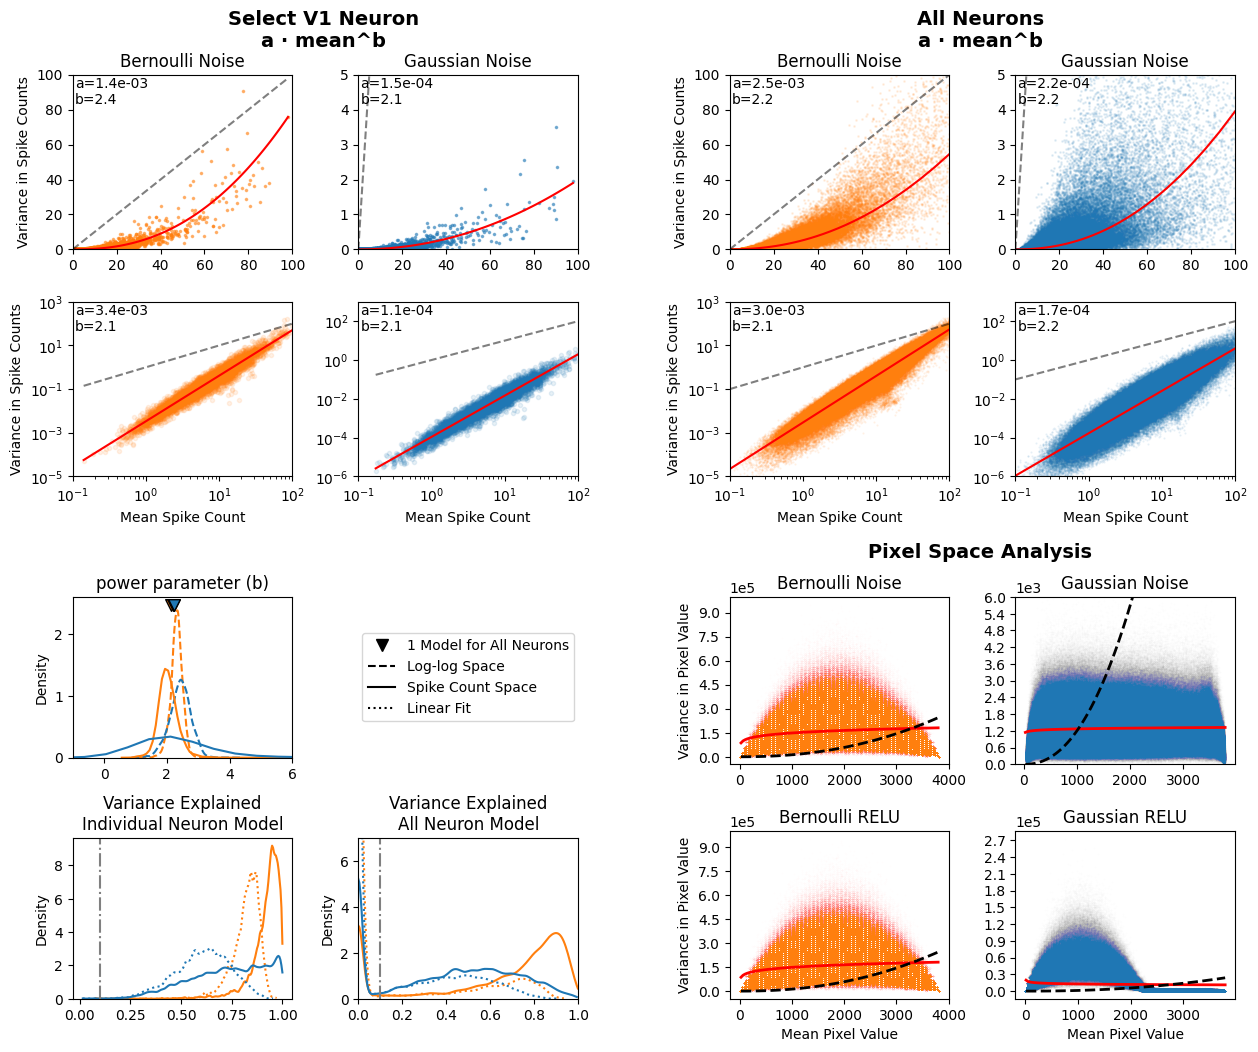

In [17]:
# Then run the fitting (cell 21) to get all the fit parameters

# Finally, plot the figure
fig = plot_figure1(
     stochbin_meanv1, stochbin_varv1, sigma10_meanv1, sigma10_varv1,
     pixel_data['gnoise_mean'], pixel_data['gnoise_var'],
     pixel_data['bnoise_mean'], pixel_data['bnoise_var'],
     pixel_data['fg_mean_relu'], pixel_data['fg_var_relu'],
     pixel_data['fb_mean_relu'], pixel_data['fb_var_relu'],
     stochbin_rsqlist_lin, sigma10_rsqlist_lin,
     stochbin_rsqlist_lin_model, sigma10_rsqlist_lin_model,
     pooled_stochbin_lin, pooled_sigma10_lin,
     pooled_stochbin_lin_model, pooled_sigma10_lin_model,
     stochbin_blist_lin, sigma10_blist_lin,
     a_glob_st_lin, b_glob_st_lin, a_glob_sg_lin, b_glob_sg_lin,
     params_b_pixel, params_br_pixel, params_g_pixel, params_gr_pixel,
     x_fit_b, y_fit_b, x_fit_br, y_fit_br,
     x_fit_g, y_fit_g, x_fit_gr, y_fit_gr,
     x_pooled_b, y_pooled_b, x_pooled_br, y_pooled_br,
     x_pooled_g, y_pooled_g, x_pooled_gr, y_pooled_gr,
     savefig=False
 )

# pixel space plot

In [18]:
image_df = np.load("image_stacks/imagestack_nov232025(first100).npy") # note using first 100 here

def get_noise_per_image(img, num_frames, num_noise_seeds, noise_type: str, sigma: int, stoch_bin_param):
    if img.ndim != 3: img = np.array(img).reshape((1, img.shape[0], img.shape[1]))
    tiled_img = np.tile(img, (num_frames, 1, 1))
    return np.array(noise_iterations("_", "_", noise_type, num_noise_seeds, tiled_img, sigma, stochastic_bin_param=stoch_bin_param, 
                                     scans=[[4,7]], num_frames=num_frames, return_noise=True))

num_imgs=100
num_noise_seeds=10
num_frames=15
noise_arr_gaus = np.empty((num_imgs, num_noise_seeds, num_frames, 144, 256))
noise_arr_bern = np.empty((num_imgs, num_noise_seeds, num_frames, 144, 256))
for i in range(num_imgs): noise_arr_gaus[i] = get_noise_per_image(image_df[i], num_frames, num_noise_seeds, "dynamic", 10, False)
for i in range(num_imgs): noise_arr_bern[i] = get_noise_per_image(image_df[i], num_frames, num_noise_seeds, "dynamic", 10, True)

num_frames=1
gaus_1frame = np.empty((num_imgs, num_noise_seeds, num_frames, 144, 256))
bern_1frame = np.empty((num_imgs, num_noise_seeds, num_frames, 144, 256))
for i in range(num_imgs): gaus_1frame[i] = get_noise_per_image(image_df[i], num_frames, num_noise_seeds, "dynamic", 10, False)
for i in range(num_imgs): bern_1frame[i] = get_noise_per_image(image_df[i], num_frames, num_noise_seeds, "dynamic", 10, True)

In [19]:
noise_arr_fg = noise_arr_gaus.reshape(num_imgs, num_noise_seeds, 15, 144*256).astype(np.float32)
noise_arr_bern = noise_arr_bern.reshape(num_imgs, num_noise_seeds, 15, 144*256).astype(np.float32)

# Create unique patterns for each image-noise_seed combination
total_pixels = 144 * 256
base_pattern = np.arange(256)

# Create different starting offsets for each combination
gaus_1frame = np.zeros((num_imgs, num_noise_seeds, 1, total_pixels), dtype=np.float32)
bern_1frame = np.zeros((num_imgs, num_noise_seeds, 1, total_pixels), dtype=np.float32)

for i in range(num_imgs):
    for j in range(num_noise_seeds):
        # Different offset for each combination
        offset = (i * num_noise_seeds + j) % 256
        shifted_pattern = np.roll(base_pattern, offset)
        full_pattern = np.tile(shifted_pattern, int(np.ceil(total_pixels / 256)))[:total_pixels]
        gaus_1frame[i, j, 0] = full_pattern
        bern_1frame[i, j, 0] = full_pattern

KeyboardInterrupt: 

In [ ]:
# 15 FRAMES
# regular data
gaus_summed = np.sum(noise_arr_fg, axis = 2)
gnoise_mean = np.mean(gaus_summed, axis=1)
gnoise_var = np.var(gaus_summed, axis=1)

bern_summed = np.sum(noise_arr_bern, axis=2)
bnoise_mean = np.mean(bern_summed, axis=1)
bnoise_var = np.var(bern_summed, axis=1)

# get RELU data here
fg_relu = np.where(noise_arr_fg>=128, noise_arr_fg, 0)
grelu_sum = np.sum(fg_relu, axis=2)
fg_mean_relu = np.mean(grelu_sum, axis=1).flatten()
fg_var_relu = np.var(grelu_sum, axis=1).flatten()

fb_relu = np.where(noise_arr_bern>=128, noise_arr_bern, 0)
fb_relu_sum = np.sum(fb_relu, axis=2)
fb_mean_relu = np.mean(fb_relu_sum, axis=1).flatten()
fb_var_relu = np.var(fb_relu_sum, axis=1).flatten()

In [ ]:
from scipy.optimize import curve_fit

def power_law(x, a, b):
    return a * (x ** b)

# Fit Bernoulli data
mask_b = (bnoise_mean > 0) & (bnoise_var > 0) & np.isfinite(bnoise_mean) & np.isfinite(bnoise_var)
if mask_b.sum() > 2:
    params_b_pixel, _ = curve_fit(power_law, bnoise_mean[mask_b], bnoise_var[mask_b], 
                                    maxfev=1_000_000, p0=[1, 2])
    x_fit_b = np.linspace(bnoise_mean[mask_b].min(), bnoise_mean[mask_b].max(), 100)
    y_fit_b = power_law(x_fit_b, *params_b_pixel)
else:
    params_b_pixel = None
    x_fit_b, y_fit_b = None, None

# Calculate pooled Bernoulli regression
try:
    if np.isfinite(a_glob_st_lin) and np.isfinite(b_glob_st_lin):
        x_pooled_b = np.linspace(bnoise_mean[mask_b].min(), bnoise_mean[mask_b].max(), 100)
        y_pooled_b = power_law(x_pooled_b, a_glob_st_lin, b_glob_st_lin)
    else:
        x_pooled_b, y_pooled_b = None, None
except NameError:
    x_pooled_b, y_pooled_b = None, None
    a_glob_st_lin, b_glob_st_lin = None, None

# Fit Bernoulli ReLU data
mask_br = (fb_mean_relu > 0) & (fb_var_relu > 0) & np.isfinite(fb_mean_relu) & np.isfinite(fb_var_relu)
if mask_br.sum() > 2:
    params_br_pixel, _ = curve_fit(power_law, fb_mean_relu[mask_br], fb_var_relu[mask_br], 
                                     maxfev=1_000_000, p0=[1, 2])
    x_fit_br = np.linspace(fb_mean_relu[mask_br].min(), fb_mean_relu[mask_br].max(), 100)
    y_fit_br = power_law(x_fit_br, *params_br_pixel)
else:
    params_br_pixel = None
    x_fit_br, y_fit_br = None, None

# Calculate pooled Bernoulli ReLU regression
try:
    if np.isfinite(a_glob_st_lin) and np.isfinite(b_glob_st_lin):
        x_pooled_br = np.linspace(fb_mean_relu[mask_br].min(), fb_mean_relu[mask_br].max(), 100)
        y_pooled_br = power_law(x_pooled_br, a_glob_st_lin, b_glob_st_lin)
    else:
        x_pooled_br, y_pooled_br = None, None
except NameError:
    x_pooled_br, y_pooled_br = None, None

# Fit Gaussian data
mask_g = (gnoise_mean > 0) & (gnoise_var > 0) & np.isfinite(gnoise_mean) & np.isfinite(gnoise_var)
if mask_g.sum() > 2:
    params_g_pixel, _ = curve_fit(power_law, gnoise_mean[mask_g], gnoise_var[mask_g], 
                                    maxfev=1_000_000, p0=[1, 2])
    x_fit_g = np.linspace(gnoise_mean[mask_g].min(), gnoise_mean[mask_g].max(), 100)
    y_fit_g = power_law(x_fit_g, *params_g_pixel)
else:
    params_g_pixel = None
    x_fit_g, y_fit_g = None, None

# Calculate pooled Gaussian regression
try:
    if np.isfinite(a_glob_sg_lin) and np.isfinite(b_glob_sg_lin):
        x_pooled_g = np.linspace(gnoise_mean[mask_g].min(), gnoise_mean[mask_g].max(), 100)
        y_pooled_g = power_law(x_pooled_g, a_glob_sg_lin, b_glob_sg_lin)
    else:
        x_pooled_g, y_pooled_g = None, None
except NameError:
    x_pooled_g, y_pooled_g = None, None
    a_glob_sg_lin, b_glob_sg_lin = None, None

# Fit Gaussian ReLU data
mask_gr = (fg_mean_relu > 0) & (fg_var_relu > 0) & np.isfinite(fg_mean_relu) & np.isfinite(fg_var_relu)
if mask_gr.sum() > 2:
    params_gr_pixel, _ = curve_fit(power_law, fg_mean_relu[mask_gr], fg_var_relu[mask_gr], 
                                     maxfev=1_000_000, p0=[1, 2])
    x_fit_gr = np.linspace(fg_mean_relu[mask_gr].min(), fg_mean_relu[mask_gr].max(), 100)
    y_fit_gr = power_law(x_fit_gr, *params_gr_pixel)
else:
    params_gr_pixel = None
    x_fit_gr, y_fit_gr = None, None

# Calculate pooled Gaussian ReLU regression
try:
    if np.isfinite(a_glob_sg_lin) and np.isfinite(b_glob_sg_lin):
        x_pooled_gr = np.linspace(fg_mean_relu[mask_gr].min(), fg_mean_relu[mask_gr].max(), 100)
        y_pooled_gr = power_law(x_pooled_gr, a_glob_sg_lin, b_glob_sg_lin)
    else:
        x_pooled_gr, y_pooled_gr = None, None
except NameError:
    x_pooled_gr, y_pooled_gr = None, None

In [ ]:
# Plot pixel-level noise analysis
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Left column: Bernoulli
axes[0, 0].scatter(bnoise_mean, bnoise_var, marker=".", alpha=0.006, s=1.001, color='tab:orange')
if x_fit_b is not None:
    axes[0, 0].plot(x_fit_b, y_fit_b, 'r-', linewidth=2, label=f'Fit: a={params_b_pixel[0]:.2e}, b={params_b_pixel[1]:.2f}')
if x_pooled_b is not None:
    axes[0, 0].plot(x_pooled_b, y_pooled_b, 'k--', linewidth=2, label=f'Pooled: a={a_glob_st_lin:.2e}, b={b_glob_st_lin:.2f}')
axes[0, 0].set_xlabel("Mean")
axes[0, 0].set_ylabel("Variance in Pixel Value")
axes[0, 0].set_title("Bernoulli Noise")
axes[0, 0].legend(loc='upper left', fontsize=8)
axes[0, 0].ticklabel_format(axis='y', style='scientific', scilimits=(0,0))

axes[1, 0].scatter(fb_mean_relu, fb_var_relu, marker=".", alpha=0.006, s=1.001, color='tab:orange')
if x_fit_br is not None:
    axes[1, 0].plot(x_fit_br, y_fit_br, 'r-', linewidth=2, label=f'Fit: a={params_br_pixel[0]:.2e}, b={params_br_pixel[1]:.2f}')
if x_pooled_br is not None:
    axes[1, 0].plot(x_pooled_br, y_pooled_br, 'k--', linewidth=2, label=f'Pooled: a={a_glob_st_lin:.2e}, b={b_glob_st_lin:.2f}')
axes[1, 0].set_xlabel("Mean")
axes[1, 0].set_ylabel("Variance in Pixel Value")
axes[1, 0].set_title("Bernoulli Noise (ReLU)")
axes[1, 0].legend(loc='upper left', fontsize=8)
axes[1, 0].ticklabel_format(axis='y', style='scientific', scilimits=(0,0))

# Right column: Gaussian
axes[0, 1].scatter(gnoise_mean, gnoise_var, marker=".", alpha=0.006, s=1.001, color='tab:blue')
if x_fit_g is not None:
    axes[0, 1].plot(x_fit_g, y_fit_g, 'r-', linewidth=2, label=f'Fit: a={params_g_pixel[0]:.2e}, b={params_g_pixel[1]:.2f}')
if x_pooled_g is not None:
    axes[0, 1].plot(x_pooled_g, y_pooled_g, 'k--', linewidth=2, label=f'Pooled: a={a_glob_sg_lin:.2e}, b={b_glob_sg_lin:.2f}')
axes[0, 1].set_xlabel("Mean")
axes[0, 1].set_ylabel("Variance in Pixel Value")
axes[0, 1].set_title("Gaussian Noise")
axes[0,1].set_ylim(0, 4000)
axes[0, 1].ticklabel_format(axis='y', style='scientific', scilimits=(0,0))

axes[1, 1].scatter(fg_mean_relu, fg_var_relu, marker=".", alpha=0.006, s=1.001, color='tab:blue')
if x_fit_gr is not None:
    axes[1, 1].plot(x_fit_gr, y_fit_gr, 'r-', linewidth=2, label=f'Fit: a={params_gr_pixel[0]:.2e}, b={params_gr_pixel[1]:.2f}')
if x_pooled_gr is not None:
    axes[1, 1].plot(x_pooled_gr, y_pooled_gr, 'k--', linewidth=2, label=f'Pooled: a={a_glob_sg_lin:.2e}, b={b_glob_sg_lin:.2f}')
axes[1, 1].set_xlabel("Mean")
axes[1, 1].set_ylabel("Variance in Pixel Value")
axes[1, 1].set_title("Gaussian Noise (ReLU)")
axes[1, 1].ticklabel_format(axis='y', style='scientific', scilimits=(0,0))
#axes[1,1].set_ylim(0, 6000)

plt.tight_layout()

plt.show()
plt.show()

In [ ]:
# Calculate data for 1 frame Bernoulli noise
bern_1frame_summed = np.sum(bern_1frame, axis=2)
# Reshape to (num_imgs * num_noise_seeds, pixel_flattened) for proper statistics
bern_1frame_flat = bern_1frame_summed.reshape(bern_1frame_summed.shape[0]*bern_1frame_summed.shape[1], -1)
bern_1frame_mean = np.mean(bern_1frame_flat, axis=1).flatten()
bern_1frame_var = np.var(bern_1frame_flat, axis=1).flatten()

# ReLU for 1 frame
fb_1frame_relu = np.where(bern_1frame>=128, bern_1frame, 0)
fb_1frame_relu_sum = np.sum(fb_1frame_relu, axis=2)
# Reshape to (num_imgs * num_noise_seeds, pixel_flattened) for proper statistics
fb_1frame_relu_flat = fb_1frame_relu_sum.reshape(fb_1frame_relu_sum.shape[0]*fb_1frame_relu_sum.shape[1], -1)
fb_1frame_mean_relu = np.mean(fb_1frame_relu_flat, axis=1).flatten()
fb_1frame_var_relu = np.var(fb_1frame_relu_flat, axis=1).flatten()

In [ ]:
# Fit 1 frame Bernoulli data
mask_b1 = (bern_1frame_mean > 0) & (bern_1frame_var > 0) & np.isfinite(bern_1frame_mean) & np.isfinite(bern_1frame_var)
if mask_b1.sum() > 2:
    params_b1_pixel, _ = curve_fit(power_law, bern_1frame_mean[mask_b1], bern_1frame_var[mask_b1], 
                                    maxfev=1_000_000, p0=[1, 2])
    x_fit_b1 = np.linspace(bern_1frame_mean[mask_b1].min(), bern_1frame_mean[mask_b1].max(), 100)
    y_fit_b1 = power_law(x_fit_b1, *params_b1_pixel)
else:
    params_b1_pixel = None
    x_fit_b1, y_fit_b1 = None, None

# Fit 1 frame Bernoulli ReLU data
mask_br1 = (fb_1frame_mean_relu > 0) & (fb_1frame_var_relu > 0) & np.isfinite(fb_1frame_mean_relu) & np.isfinite(fb_1frame_var_relu)
if mask_br1.sum() > 2:
    params_br1_pixel, _ = curve_fit(power_law, fb_1frame_mean_relu[mask_br1], fb_1frame_var_relu[mask_br1], 
                                     maxfev=1_000_000, p0=[1, 2])
    x_fit_br1 = np.linspace(fb_1frame_mean_relu[mask_br1].min(), fb_1frame_mean_relu[mask_br1].max(), 100)
    y_fit_br1 = power_law(x_fit_br1, *params_br1_pixel)
else:
    params_br1_pixel = None
    x_fit_br1, y_fit_br1 = None, None

# Plot pixel-level noise analysis: 1 frame vs 15 frames for Bernoulli
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Left column: 1 frame
#axes[0, 0].scatter(bern_1frame_mean, bern_1frame_var, marker=".", alpha=0.006, s=1.001, color='tab:orange')
axes[0, 0].scatter(bern_1frame_mean, bern_1frame_var, marker=".",  color='tab:orange')

if x_fit_b1 is not None:
    axes[0, 0].plot(x_fit_b1, y_fit_b1, 'r-', linewidth=2, label=f'Fit: a={params_b1_pixel[0]:.2e}, b={params_b1_pixel[1]:.2f}')
if x_pooled_b is not None and a_glob_st_lin is not None and b_glob_st_lin is not None:
    if np.isfinite(a_glob_st_lin) and np.isfinite(b_glob_st_lin):
        x_pooled_b1 = np.linspace(bern_1frame_mean[mask_b1].min(), bern_1frame_mean[mask_b1].max(), 100)
        y_pooled_b1 = power_law(x_pooled_b1, a_glob_st_lin, b_glob_st_lin)
        axes[0, 0].plot(x_pooled_b1, y_pooled_b1, 'k--', linewidth=2, label=f'Pooled: a={a_glob_st_lin:.2e}, b={b_glob_st_lin:.2f}')
axes[0, 0].set_xlabel("Mean")
axes[0, 0].set_ylabel("Variance in Pixel Value")
axes[0, 0].set_title("Bernoulli Noise (1 Frame)")
axes[0, 0].legend(loc='upper left', fontsize=8)
axes[0, 0].ticklabel_format(axis='y', style='scientific', scilimits=(0,0))

#axes[1, 0].scatter(fb_1frame_mean_relu, fb_1frame_var_relu, marker=".", alpha=0.006, s=1.001, color='tab:orange')
axes[1, 0].scatter(fb_1frame_mean_relu, fb_1frame_var_relu, marker=".", color='tab:orange')
if x_fit_br1 is not None:
    axes[1, 0].plot(x_fit_br1, y_fit_br1, 'r-', linewidth=2, label=f'Fit: a={params_br1_pixel[0]:.2e}, b={params_br1_pixel[1]:.2f}')
if x_pooled_br is not None and a_glob_st_lin is not None and b_glob_st_lin is not None:
    if np.isfinite(a_glob_st_lin) and np.isfinite(b_glob_st_lin):
        x_pooled_br1 = np.linspace(fb_1frame_mean_relu[mask_br1].min(), fb_1frame_mean_relu[mask_br1].max(), 100)
        y_pooled_br1 = power_law(x_pooled_br1, a_glob_st_lin, b_glob_st_lin)
        axes[1, 0].plot(x_pooled_br1, y_pooled_br1, 'k--', linewidth=2, label=f'Pooled: a={a_glob_st_lin:.2e}, b={b_glob_st_lin:.2f}')
axes[1, 0].set_xlabel("Mean")
axes[1, 0].set_ylabel("Variance in Pixel Value")
axes[1, 0].set_title("Bernoulli Noise (1 Frame, ReLU)")
axes[1, 0].legend(loc='upper left', fontsize=8)
axes[1, 0].ticklabel_format(axis='y', style='scientific', scilimits=(0,0))

# Right column: 15 frames
axes[0, 1].scatter(bnoise_mean, bnoise_var, marker=".", alpha=0.006, s=1.001, color='tab:orange')

if x_fit_b is not None:
    axes[0, 1].plot(x_fit_b, y_fit_b, 'r-', linewidth=2, label=f'Fit: a={params_b_pixel[0]:.2e}, b={params_b_pixel[1]:.2f}')
if x_pooled_b is not None:
    axes[0, 1].plot(x_pooled_b, y_pooled_b, 'k--', linewidth=2, label=f'Pooled: a={a_glob_st_lin:.2e}, b={b_glob_st_lin:.2f}')
axes[0, 1].set_xlabel("Mean")
axes[0, 1].set_ylabel("Variance in Pixel Value")
axes[0, 1].set_title("Bernoulli Noise (15 Frames)")
axes[0, 1].legend(loc='upper left', fontsize=8)
axes[0, 1].ticklabel_format(axis='y', style='scientific', scilimits=(0,0))

axes[1, 1].scatter(fb_mean_relu, fb_var_relu, marker=".", alpha=0.006, s=1.001, color='tab:orange')
if x_fit_br is not None:
    axes[1, 1].plot(x_fit_br, y_fit_br, 'r-', linewidth=2, label=f'Fit: a={params_br_pixel[0]:.2e}, b={params_br_pixel[1]:.2f}')
if x_pooled_br is not None:
    axes[1, 1].plot(x_pooled_br, y_pooled_br, 'k--', linewidth=2, label=f'Pooled: a={a_glob_st_lin:.2e}, b={b_glob_st_lin:.2f}')
axes[1, 1].set_xlabel("Mean")
axes[1, 1].set_ylabel("Variance in Pixel Value")
axes[1, 1].set_title("Bernoulli Noise (15 Frames, ReLU)")
axes[1, 1].legend(loc='upper left', fontsize=8)
axes[1, 1].ticklabel_format(axis='y', style='scientific', scilimits=(0,0))

plt.tight_layout()
plt.show()

In [ ]:
# Calculate data for 1 frame Gaussian noise
gaus_1frame_summed = np.sum(gaus_1frame, axis=2)
# Reshape to (num_imgs * num_noise_seeds, pixel_flattened) for proper statistics
gaus_1frame_flat = gaus_1frame_summed.reshape(gaus_1frame_summed.shape[0]*gaus_1frame_summed.shape[1], -1)
gaus_1frame_mean = np.mean(gaus_1frame_flat, axis=1).flatten()
gaus_1frame_var = np.var(gaus_1frame_flat, axis=1).flatten()

# ReLU for 1 frame
fg_1frame_relu = np.where(gaus_1frame>=128, gaus_1frame, 0)
fg_1frame_relu_sum = np.sum(fg_1frame_relu, axis=2)
# Reshape to (num_imgs * num_noise_seeds, pixel_flattened) for proper statistics
fg_1frame_relu_flat = fg_1frame_relu_sum.reshape(fg_1frame_relu_sum.shape[0]*fg_1frame_relu_sum.shape[1], -1)
fg_1frame_mean_relu = np.mean(fg_1frame_relu_flat, axis=1).flatten()
fg_1frame_var_relu = np.var(fg_1frame_relu_flat, axis=1).flatten()

# Fit 1 frame Gaussian data
mask_g1 = (gaus_1frame_mean > 0) & (gaus_1frame_var > 0) & np.isfinite(gaus_1frame_mean) & np.isfinite(gaus_1frame_var)
if mask_g1.sum() > 2:
    params_g1_pixel, _ = curve_fit(power_law, gaus_1frame_mean[mask_g1], gaus_1frame_var[mask_g1], 
                                    maxfev=1_000_000, p0=[1, 2])
    x_fit_g1 = np.linspace(gaus_1frame_mean[mask_g1].min(), gaus_1frame_mean[mask_g1].max(), 100)
    y_fit_g1 = power_law(x_fit_g1, *params_g1_pixel)
else:
    params_g1_pixel = None
    x_fit_g1, y_fit_g1 = None, None

# Fit 1 frame Gaussian ReLU data
mask_gr1 = (fg_1frame_mean_relu > 0) & (fg_1frame_var_relu > 0) & np.isfinite(fg_1frame_mean_relu) & np.isfinite(fg_1frame_var_relu)
if mask_gr1.sum() > 2:
    params_gr1_pixel, _ = curve_fit(power_law, fg_1frame_mean_relu[mask_gr1], fg_1frame_var_relu[mask_gr1], 
                                     maxfev=1_000_000, p0=[1, 2])
    x_fit_gr1 = np.linspace(fg_1frame_mean_relu[mask_gr1].min(), fg_1frame_mean_relu[mask_gr1].max(), 100)
    y_fit_gr1 = power_law(x_fit_gr1, *params_gr1_pixel)
else:
    params_gr1_pixel = None
    x_fit_gr1, y_fit_gr1 = None, None

# Plot pixel-level noise analysis: 1 frame vs 15 frames for Gaussian
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Left column: 1 frame
axes[0, 0].scatter(gaus_1frame_mean, gaus_1frame_var, marker=".", color='tab:blue')
if x_fit_g1 is not None:
    axes[0, 0].plot(x_fit_g1, y_fit_g1, 'r-', linewidth=2, label=f'Fit: a={params_g1_pixel[0]:.2e}, b={params_g1_pixel[1]:.2f}')
if x_pooled_g is not None and a_glob_sg_lin is not None and b_glob_sg_lin is not None:
    if np.isfinite(a_glob_sg_lin) and np.isfinite(b_glob_sg_lin):
        x_pooled_g1 = np.linspace(gaus_1frame_mean[mask_g1].min(), gaus_1frame_mean[mask_g1].max(), 100)
        y_pooled_g1 = power_law(x_pooled_g1, a_glob_sg_lin, b_glob_sg_lin)
        axes[0, 0].plot(x_pooled_g1, y_pooled_g1, 'k--', linewidth=2, label=f'Pooled: a={a_glob_sg_lin:.2e}, b={b_glob_sg_lin:.2f}')
axes[0, 0].set_xlabel("Mean")
axes[0, 0].set_ylabel("Variance in Pixel Value")
axes[0, 0].set_title("Gaussian Noise (1 Frame)")
axes[0, 0].legend(loc='upper left', fontsize=8)
axes[0, 0].ticklabel_format(axis='y', style='scientific', scilimits=(0,0))

axes[1, 0].scatter(fg_1frame_mean_relu, fg_1frame_var_relu, marker=".", color='tab:blue')
if x_fit_gr1 is not None:
    axes[1, 0].plot(x_fit_gr1, y_fit_gr1, 'r-', linewidth=2, label=f'Fit: a={params_gr1_pixel[0]:.2e}, b={params_gr1_pixel[1]:.2f}')
if x_pooled_gr is not None and a_glob_sg_lin is not None and b_glob_sg_lin is not None:
    if np.isfinite(a_glob_sg_lin) and np.isfinite(b_glob_sg_lin):
        x_pooled_gr1 = np.linspace(fg_1frame_mean_relu[mask_gr1].min(), fg_1frame_mean_relu[mask_gr1].max(), 100)
        y_pooled_gr1 = power_law(x_pooled_gr1, a_glob_sg_lin, b_glob_sg_lin)
        axes[1, 0].plot(x_pooled_gr1, y_pooled_gr1, 'k--', linewidth=2, label=f'Pooled: a={a_glob_sg_lin:.2e}, b={b_glob_sg_lin:.2f}')
axes[1, 0].set_xlabel("Mean")
axes[1, 0].set_ylabel("Variance in Pixel Value")
axes[1, 0].set_title("Gaussian Noise (1 Frame, ReLU)")
axes[1, 0].legend(loc='upper left', fontsize=8)
axes[1, 0].ticklabel_format(axis='y', style='scientific', scilimits=(0,0))

# Right column: 15 frames
axes[0, 1].scatter(gnoise_mean, gnoise_var, marker=".", alpha=0.006, s=1.001, color='tab:blue')
if x_fit_g is not None:
    axes[0, 1].plot(x_fit_g, y_fit_g, 'r-', linewidth=2, label=f'Fit: a={params_g_pixel[0]:.2e}, b={params_g_pixel[1]:.2f}')
if x_pooled_g is not None:
    axes[0, 1].plot(x_pooled_g, y_pooled_g, 'k--', linewidth=2, label=f'Pooled: a={a_glob_sg_lin:.2e}, b={b_glob_sg_lin:.2f}')
axes[0, 1].set_xlabel("Mean")
axes[0, 1].set_ylabel("Variance in Pixel Value")
axes[0, 1].set_title("Gaussian Noise (15 Frames)")
axes[0, 1].set_ylim(0, 4000)
axes[0, 1].legend(loc='upper left', fontsize=8)
axes[0, 1].ticklabel_format(axis='y', style='scientific', scilimits=(0,0))

axes[1, 1].scatter(fg_mean_relu, fg_var_relu, marker=".", alpha=0.006, s=1.001, color='tab:blue')
if x_fit_gr is not None:
    axes[1, 1].plot(x_fit_gr, y_fit_gr, 'r-', linewidth=2, label=f'Fit: a={params_gr_pixel[0]:.2e}, b={params_gr_pixel[1]:.2f}')
if x_pooled_gr is not None:
    axes[1, 1].plot(x_pooled_gr, y_pooled_gr, 'k--', linewidth=2, label=f'Pooled: a={a_glob_sg_lin:.2e}, b={b_glob_sg_lin:.2f}')
axes[1, 1].set_xlabel("Mean")
axes[1, 1].set_ylabel("Variance in Pixel Value")
axes[1, 1].set_title("Gaussian Noise (15 Frames, ReLU)")
axes[1, 1].legend(loc='upper left', fontsize=8)
axes[1, 1].ticklabel_format(axis='y', style='scientific', scilimits=(0,0))

plt.tight_layout()
plt.show()

# Get image noise JPEG

In [46]:
noise_frames=9
test_img = image_df[0]
noise = get_noise_per_image(test_img, noise_frames, 1, "dynamic", 10, False)
noise = noise.reshape(noise_frames, 144, 256)
print(noise.shape)

(9, 144, 256)


In [47]:
from PIL import Image
import numpy as np

og_img = Image.fromarray(test_img.astype("uint8"))
folder = "image_jpeg/"
og_img.save(f"{folder}og_img.png")

#Noise image
for i in range(noise.shape[0]):
    noise_img = Image.fromarray(noise[i].astype("uint8").reshape(144, 256))
    noise_img.save(f"{folder}frame{i}.png")